In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [14]:
df_first = pd.read_csv("./data/vn30_filtered.csv")
df_first

,symbol,time,close,volume,vnindex
0,ACB,2017-01-03,3.33,1609757,672.01
1,ACB,2017-01-04,3.35,739000,674.70
2,ACB,2017-01-05,3.35,471881,675.81
3,ACB,2017-01-06,3.53,1409824,679.80
4,ACB,2017-01-09,3.65,970791,682.57
...,...,...,...,...,...
53045,VRE,2025-12-25,32.25,17089700,1742.85
53046,VRE,2025-12-26,32.00,20927400,1729.80
53047,VRE,2025-12-29,33.20,7573400,1754.84
53048,VRE,2025-12-30,32.80,8839700,1766.90


# Add feature

In [15]:
def _get_prefix(col_name):
    mapping = {
        "close": "stock",
        "vnindex": "market",
        "stock_lret_1": "stock",
        "market_lret_1": "market"
    }

    if col_name.startswith("idio_lret"):
        return "idio"
    
    return mapping.get(col_name, col_name)

In [16]:
def compute_log_return(
    df=None,
    computed_cols=["close", "vnindex"],
    shifts=[1],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for computed_col in computed_cols:
        df[computed_col] = df[computed_col].replace(0, np.nan)
        prefix = _get_prefix(computed_col)
        
        for shift in shifts:
            col_name = f"{prefix}_lret_{shift}"
            df[col_name] = (
                df.groupby(group_col)[computed_col].transform(
                    lambda x: np.log(x / x.shift(shift))
                )
            )

    return df

In [17]:
def compute_momentum(
    df=None,
    computed_cols=["stock_lret_1", "market_lret_1"],
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for computed_col in computed_cols:
        prefix = _get_prefix(computed_col)
        
        for window in windows:
            col_name = f"{prefix}_mom_{window}"
            df[col_name] = (
                df.groupby(group_col)[computed_col].transform(
                    lambda x: x.rolling(window).sum()
                )
            )

    return df

In [18]:
def compute_volatility(
    df=None,
    computed_cols=["stock_lret_1", "market_lret_1"],
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for computed_col in computed_cols:
        prefix = _get_prefix(computed_col)

        for window in windows:
            col_name = f"{prefix}_vol_{window}"
            df[col_name] = (
                df.groupby(group_col)[computed_col].transform(
                    lambda x: x.rolling(window).std()
                )
            )

    return df

In [19]:
def compute_beta(
    df=None,
    stock_col="stock_lret_1",
    market_col="market_lret_1",
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for window in windows:
        beta_col = f"beta_{window}"

        df[beta_col] = (
            df.groupby(group_col).apply(
                lambda x: x[stock_col].rolling(window).cov(x[market_col]) / x[market_col].rolling(window).var()
            ).reset_index(level=0, drop=True)
        )

    return df

In [20]:
def compute_corr(
    df=None,
    stock_col="stock_lret_1",
    market_col="market_lret_1",
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time",
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for window in windows:
        corr_col = f"corr_{window}"

        df[corr_col] = df.groupby(group_col).apply(
            lambda x: x[stock_col].rolling(window).corr(x[market_col])
        ).reset_index(level=0, drop=True)

    return df

In [21]:
def compute_idio_lret(
    df=None,
    stock_col="stock_lret_1",
    market_col="market_lret_1",
    beta_col="beta",
    windows=[10, 20, 60]
):
    df = df.copy()

    for window in windows:
        beta = f"{beta_col}_{window}"
        idio_lret_col = f"idio_lret_{window}"

        if beta not in df.columns:
            raise ValueError(f"Column '{beta}' does not exist.")

        df[idio_lret_col] = df[stock_col] - df[beta] * df[market_col]

    return df


# Idiosyncratic Volatility
def compute_idio_vol(
    df=None,
    stock_vol_prefix="stock_vol",
    market_vol_prefix="market_vol",
    beta_col_prefix="beta",
    windows=[10, 20, 60]
):
    df = df.copy()

    for window in windows:
        stock_vol = f"{stock_vol_prefix}_{window}"
        market_vol = f"{market_vol_prefix}_{window}"
        beta_col = f"{beta_col_prefix}_{window}"
        idio_vol_col = f"idio_vol_{window}"

        idio_var = df[stock_vol] ** 2 - (df[beta_col] ** 2) * (df[market_vol] ** 2)
        idio_var = np.maximum(idio_var, 0)
        df[idio_vol_col] = np.sqrt(idio_var)

    return df

In [22]:
def compute_pairwise_feature(
    df=None,
    left_prefix="stock",
    right_prefix="market",
    windows=[10, 20, 60],
    operation=None,
    output_prefix=None,
    group_col="symbol",
    time_col="time"
):
    df = df.copy()

    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    valid_operations = ["subtract", "divide"]
    if operation not in valid_operations:
        raise ValueError(f"operation must be one of {valid_operations}")

    for window in windows:
        left_col = f"{left_prefix}_{window}"
        right_col = f"{right_prefix}_{window}"

        if left_col not in df.columns:
            raise ValueError(f"Column '{left_col}' does not exist in dataframe.")
        if right_col not in df.columns:
            raise ValueError(f"Column '{right_col}' does not exist in dataframe.")

        output_col = f"{output_prefix}_{window}"

        if operation == "subtract":
            df[output_col] = df[left_col] - df[right_col]

        elif operation == "divide":
            df[output_col] = df[left_col] / df[right_col]

    return df

In [23]:

df = compute_log_return(df_first)
df = compute_pairwise_feature(df, left_prefix="stock_lret", right_prefix="market_lret", windows=[1], operation="subtract", output_prefix="excess_lret")

df = compute_momentum(df)
df = compute_volatility(df)

df = compute_pairwise_feature(df, left_prefix="stock_mom", right_prefix="market_mom", operation="subtract", output_prefix="excess_mom")
df = compute_pairwise_feature(df, left_prefix="stock_vol", right_prefix="market_vol", operation="divide", output_prefix="relative_vol")
df = compute_pairwise_feature(df, left_prefix="stock_mom", right_prefix="stock_vol", operation="divide", output_prefix="sharpe_like")

df = compute_corr(df)
df = compute_beta(df)
df = compute_idio_lret(df)
df = compute_idio_vol(df)
df = compute_momentum(df, computed_cols=[f"idio_lret_{i}" for i in [10, 20, 60]])
df = compute_pairwise_feature(df, left_prefix="idio_mom", right_prefix="idio_vol", operation="divide", output_prefix="idio_sharpe_like")

pd.set_option('display.max_columns', None)
df.head(20)

C:\Users\manh\AppData\Local\Temp\ipykernel_16108\4182793684.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[corr_col] = df.groupby(group_col).apply(
C:\Users\manh\AppData\Local\Temp\ipykernel_16108\4182793684.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[corr_col] = df.groupby(group_col).apply(
C:\Users\manh\AppData\Local\Temp\ipykernel_16108\4182793684.py:16: FutureWarning: DataFrameGroupBy.apply o

,symbol,time,close,volume,vnindex,stock_lret_1,market_lret_1,excess_lret_1,stock_mom_10,stock_mom_20,stock_mom_60,market_mom_10,market_mom_20,market_mom_60,stock_vol_10,stock_vol_20,stock_vol_60,market_vol_10,market_vol_20,market_vol_60,excess_mom_10,excess_mom_20,excess_mom_60,relative_vol_10,relative_vol_20,relative_vol_60,sharpe_like_10,sharpe_like_20,sharpe_like_60,corr_10,corr_20,corr_60,beta_10,beta_20,beta_60,idio_lret_10,idio_lret_20,idio_lret_60,idio_vol_10,idio_vol_20,idio_vol_60,idio_mom_10,idio_mom_20,idio_mom_60,idio_sharpe_like_10,idio_sharpe_like_20,idio_sharpe_like_60
0,ACB,2017-01-03,3.33,1609757,672.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ACB,2017-01-04,3.35,739000,674.70,0.005988,0.003995,0.001993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ACB,2017-01-05,3.35,471881,675.81,0.000000,0.001644,-0.001644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ACB,2017-01-06,3.53,1409824,679.80,0.052338,0.005887,0.046451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ACB,2017-01-09,3.65,970791,682.57,0.033429,0.004066,0.029363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ACB,2017-01-10,3.69,942499,681.07,0.010899,-0.002200,0.013099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ACB,2017-01-11,3.79,1447461,687.16,0.026740,0.008902,0.017837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ACB,2017-01-12,3.79,1158392,686.96,0.000000,-0.000291,0.000291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ACB,2017-01-13,3.77,1230784,685.06,-0.005291,-0.002770,-0.002521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ACB,2017-01-16,3.83,575469,677.94,0.015790,-0.010448,0.026237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53050 entries, 0 to 53049
Data columns (total 47 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   symbol               53050 non-null  object        
 1   time                 53050 non-null  datetime64[ns]
 2   close                53050 non-null  float64       
 3   volume               53050 non-null  int64         
 4   vnindex              53050 non-null  float64       
 5   stock_lret_1         53026 non-null  float64       
 6   market_lret_1        53026 non-null  float64       
 7   excess_lret_1        53026 non-null  float64       
 8   stock_mom_10         52810 non-null  float64       
 9   stock_mom_20         52570 non-null  float64       
 10  stock_mom_60         51610 non-null  float64       
 11  market_mom_10        52810 non-null  float64       
 12  market_mom_20        52570 non-null  float64       
 13  market_mom_60        51610 non-

In [25]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
time,53050,2021-07-29 02:04:42.028274944,2017-01-03 00:00:00,2019-05-20 00:00:00,2021-07-30 00:00:00,2023-10-17 00:00:00,2025-12-31 00:00:00,NaN
close,53050.0,37.428931,1.39,12.57,27.5,57.31,219.1,31.142643
volume,53050.0,5725899.447144,0.0,815846.5,2207239.0,6356197.75,249760712.0,10117486.481178
vnindex,53050.0,1120.909543,659.21,958.59,1099.49,1269.93,1784.49,233.814546
stock_lret_1,53026.0,0.000656,-0.164622,-0.008925,0.0,0.009903,1.304007,0.021763
market_lret_1,53026.0,0.000429,-0.069639,-0.004084,0.001419,0.006365,0.280823,0.012093
excess_lret_1,53026.0,0.000227,-0.114685,-0.008633,-0.001167,0.007558,1.023184,0.017118
stock_mom_10,52810.0,0.006476,-0.432595,-0.028722,0.004622,0.042255,1.371445,0.071065
stock_mom_20,52570.0,0.01284,-0.591249,-0.038376,0.00939,0.064676,1.386581,0.101481
stock_mom_60,51610.0,0.038372,-0.872745,-0.066983,0.024791,0.13374,1.386581,0.183261


# Add label

In [26]:
def add_target(df, horizon=1):
    df = df.copy()
    df["target"] = df.groupby("symbol")["stock_lret_1"].shift(-horizon)
    df['target_time'] = df.groupby('symbol')['time'].shift(-horizon)
    df = df.dropna(subset=["target"])
    return df

In [27]:
df_final = add_target(df)
df_final = df_final.drop(["close", "volume", "vnindex"], axis=1, inplace=False)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53026 entries, 0 to 53048
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   symbol               53026 non-null  object        
 1   time                 53026 non-null  datetime64[ns]
 2   stock_lret_1         53002 non-null  float64       
 3   market_lret_1        53002 non-null  float64       
 4   excess_lret_1        53002 non-null  float64       
 5   stock_mom_10         52786 non-null  float64       
 6   stock_mom_20         52546 non-null  float64       
 7   stock_mom_60         51586 non-null  float64       
 8   market_mom_10        52786 non-null  float64       
 9   market_mom_20        52546 non-null  float64       
 10  market_mom_60        51586 non-null  float64       
 11  stock_vol_10         52786 non-null  float64       
 12  stock_vol_20         52546 non-null  float64       
 13  stock_vol_60         51586 non-null 

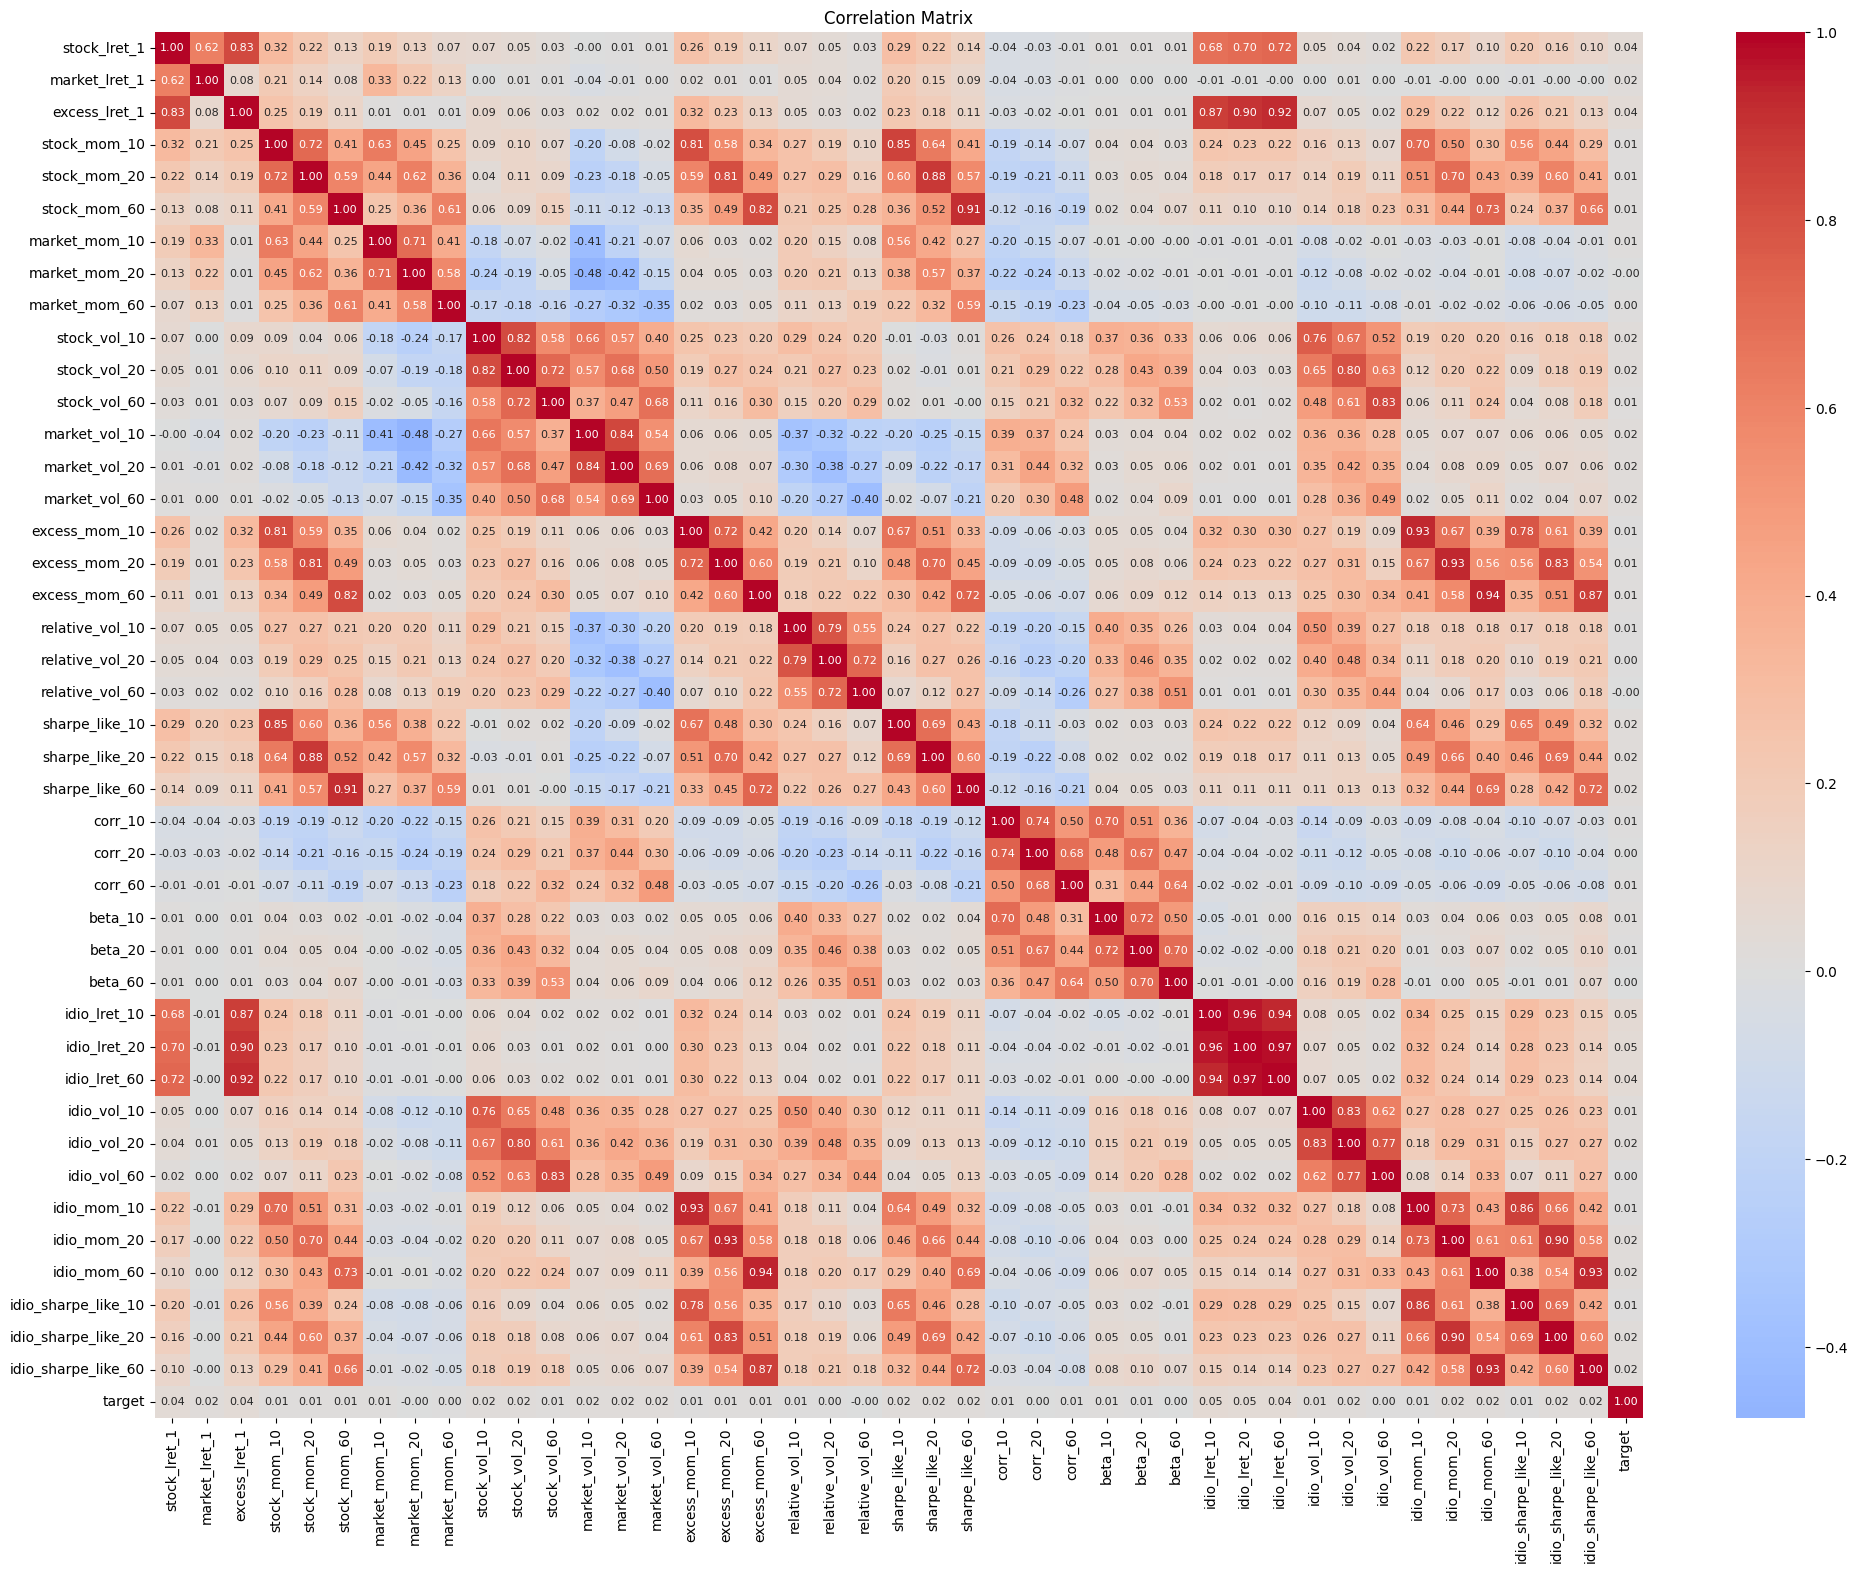

In [28]:
df_num = df_final.select_dtypes(include=["float64", "int64"])

corr = df_num.corr()

plt.figure(figsize=(24, 18))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,      
    fmt=".2f",       
    annot_kws={"size": 8}
)
plt.title("Correlation Matrix")
plt.show()

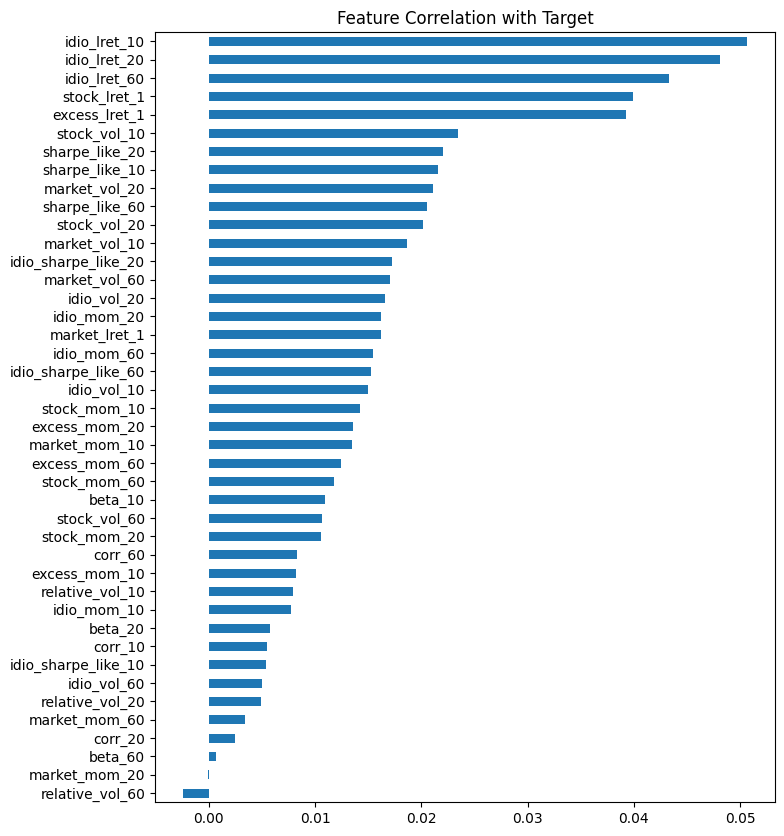

In [29]:
corr_target = df_num.corr()["target"].sort_values()

plt.figure(figsize=(8, 10))
corr_target.drop("target").plot(kind="barh")
plt.title("Feature Correlation with Target")
plt.show()

In [30]:
corr_target.sort_values(ascending=False)

target                 1.000000
idio_lret_10           0.050638
idio_lret_20           0.048076
idio_lret_60           0.043314
stock_lret_1           0.039906
excess_lret_1          0.039265
stock_vol_10           0.023417
sharpe_like_20         0.022080
sharpe_like_10         0.021549
market_vol_20          0.021132
sharpe_like_60         0.020558
stock_vol_20           0.020181
market_vol_10          0.018659
idio_sharpe_like_20    0.017221
market_vol_60          0.017082
idio_vol_20            0.016620
idio_mom_20            0.016247
market_lret_1          0.016243
idio_mom_60            0.015422
idio_sharpe_like_60    0.015301
idio_vol_10            0.014943
stock_mom_10           0.014262
excess_mom_20          0.013535
market_mom_10          0.013473
excess_mom_60          0.012395
stock_mom_60           0.011757
beta_10                0.010900
stock_vol_60           0.010658
stock_mom_20           0.010562
corr_60                0.008344
excess_mom_10          0.008198
relative

# Train/Val/Test

In [31]:
def split_time_series(df,
                      train_start='2018-01-01',
                      train_end='2023-01-01',
                      val_end='2024-01-01',
                      test_end=None,
                      time_col='time'):
    
    df = df.copy()

    train_df = df[
        (df[time_col] >= train_start) &
        (df[time_col] < train_end)
    ]

    val_df = df[
        (df[time_col] >= train_end) &
        (df[time_col] < val_end)
    ]

    if test_end is not None:
        test_df = df[
            (df[time_col] >= val_end) &
            (df[time_col] < test_end)
        ]
    else:
        test_df = df[df[time_col] >= val_end]

    return train_df, val_df, test_df

In [32]:
train_df, val_df, test_df = split_time_series(df_final)
train_df.shape, val_df.shape, test_df.shape

((29881, 46), (5976, 46), (11952, 46))

In [33]:
print(train_df['time'].min(), train_df['time'].max())
print(val_df['time'].min(), val_df['time'].max())
print(test_df['time'].min(), test_df['time'].max())

2018-01-02 00:00:00 2022-12-30 00:00:00
2023-01-03 00:00:00 2023-12-29 00:00:00
2024-01-02 00:00:00 2025-12-30 00:00:00


In [34]:
print(train_df["symbol"].nunique())
print(val_df["symbol"].nunique())
print(test_df["symbol"].nunique())

24
24
24


In [35]:
set(test_df.symbol.unique()) - set(train_df.symbol.unique())

set()

In [36]:
symbols_in_train = train_df['symbol'].unique()

test_df = test_df[test_df['symbol'].isin(symbols_in_train)]

test_df['symbol'].nunique(), test_df.shape

(24, (11952, 46))

# Create sequences

In [37]:
def create_sequences(df, window=20, feature_col='log_return', target_col='target'):
    X, y, meta = [], [], [] 
    
    for symbol, sub_df in df.groupby('symbol'):
        sub_df = sub_df.sort_values('time').reset_index(drop=True)

        values_x = sub_df[feature_col].values
        values_y = sub_df[target_col].values
        
        for i in range(len(sub_df) - window):
            X.append(values_x[i : i + window])
            y.append(values_y[i + window - 1])
            meta.append({
                'symbol': symbol,
                'time': sub_df['target_time'].iloc[i + window - 1]
            })
    
    X = np.array(X).reshape(-1, window, 1)
    y = np.array(y)
    meta_df = pd.DataFrame(meta)
    
    return X, y, meta_df

In [38]:
X_train, y_train, meta_train = create_sequences(train_df)
X_train.shape, y_train.shape, meta_train.shape

KeyError: 'log_return'

In [ ]:
X_val, y_val, meta_val = create_sequences(val_df)
X_val.shape, y_val.shape, meta_val.shape

KeyError: 'log_return'

In [ ]:
X_test, y_test, meta_test = create_sequences(test_df)
X_test.shape, y_test.shape, meta_test.shape

KeyError: 'log_return'

In [ ]:
34511+20*29, 6641+20*29, 13862+20*29

(35091, 7221, 14442)

# Building LSTM